**Práctica 2**

Dada una muestra de tamaño 150 de observaciones de las variables X e Y:

a) Dibujar e interpretar el gráfico de dispersión entre las dos variables. Tendria sentido aplicar regresión lineal?

b) Calcular manualmente los coeficientes Beta (ß) del problema de regresión de Y sobre X.

c) Comparar los coeficientes obtenidos con los datos por la libreria scikit-learn.

In [1]:
# Importar las librerias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# Importar dataset 'iris'
iris = sns.load_dataset('iris')

In [3]:
# Asignando valores a Variables A y B
A = iris['sepal_length'].values # Variable independiente (predictora)
B = iris['petal_length'].values # Se toma como target la longitud de los pétalos

In [4]:
# Calculamos la media de A
A.mean()

np.float64(5.843333333333334)

In [5]:
# Calculamos desviación estandar
A.std()

np.float64(0.8253012917851409)

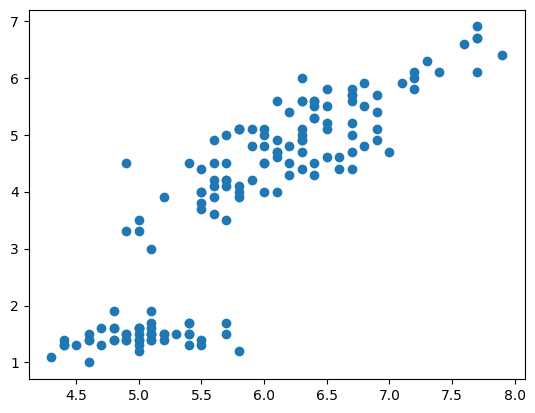

In [6]:
# Graficar scatter
plt.scatter(A, B)

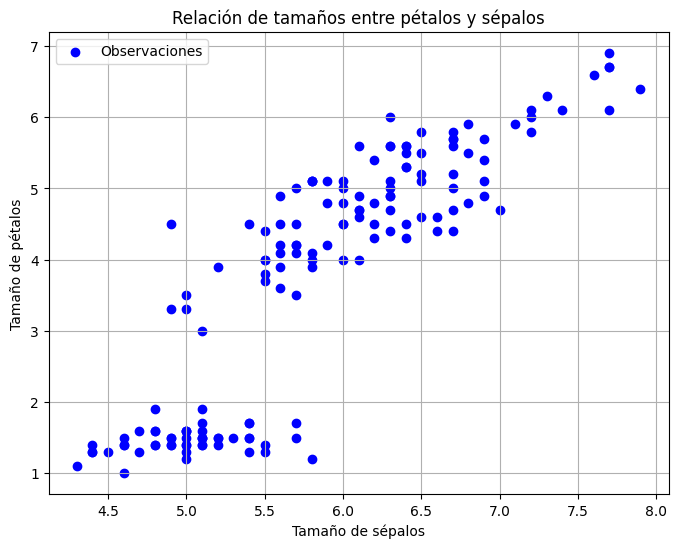

In [7]:
# Graficar los datos
plt.figure(figsize=(8, 6))
plt.scatter(A, B, color='blue', marker = 'o', label='Observaciones')
plt.xlabel('Tamaño de sépalos')
plt.ylabel('Tamaño de pétalos')
plt.title('Relación de tamaños entre pétalos y sépalos')
plt.legend()
plt.grid(True)

**Calculo de coeficientes**

In [8]:
# Calcular las medias de A y B
media_A = A.mean()
media_B = B.mean()

In [9]:
# Print A
A

array([5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.6, 5. , 4.4, 4.9, 5.4, 4.8, 4.8,
       4.3, 5.8, 5.7, 5.4, 5.1, 5.7, 5.1, 5.4, 5.1, 4.6, 5.1, 4.8, 5. ,
       5. , 5.2, 5.2, 4.7, 4.8, 5.4, 5.2, 5.5, 4.9, 5. , 5.5, 4.9, 4.4,
       5.1, 5. , 4.5, 4.4, 5. , 5.1, 4.8, 5.1, 4.6, 5.3, 5. , 7. , 6.4,
       6.9, 5.5, 6.5, 5.7, 6.3, 4.9, 6.6, 5.2, 5. , 5.9, 6. , 6.1, 5.6,
       6.7, 5.6, 5.8, 6.2, 5.6, 5.9, 6.1, 6.3, 6.1, 6.4, 6.6, 6.8, 6.7,
       6. , 5.7, 5.5, 5.5, 5.8, 6. , 5.4, 6. , 6.7, 6.3, 5.6, 5.5, 5.5,
       6.1, 5.8, 5. , 5.6, 5.7, 5.7, 6.2, 5.1, 5.7, 6.3, 5.8, 7.1, 6.3,
       6.5, 7.6, 4.9, 7.3, 6.7, 7.2, 6.5, 6.4, 6.8, 5.7, 5.8, 6.4, 6.5,
       7.7, 7.7, 6. , 6.9, 5.6, 7.7, 6.3, 6.7, 7.2, 6.2, 6.1, 6.4, 7.2,
       7.4, 7.9, 6.4, 6.3, 6.1, 7.7, 6.3, 6.4, 6. , 6.9, 6.7, 6.9, 5.8,
       6.8, 6.7, 6.7, 6.3, 6.5, 6.2, 5.9])

In [10]:
# Print B
B

array([1.4, 1.4, 1.3, 1.5, 1.4, 1.7, 1.4, 1.5, 1.4, 1.5, 1.5, 1.6, 1.4,
       1.1, 1.2, 1.5, 1.3, 1.4, 1.7, 1.5, 1.7, 1.5, 1. , 1.7, 1.9, 1.6,
       1.6, 1.5, 1.4, 1.6, 1.6, 1.5, 1.5, 1.4, 1.5, 1.2, 1.3, 1.4, 1.3,
       1.5, 1.3, 1.3, 1.3, 1.6, 1.9, 1.4, 1.6, 1.4, 1.5, 1.4, 4.7, 4.5,
       4.9, 4. , 4.6, 4.5, 4.7, 3.3, 4.6, 3.9, 3.5, 4.2, 4. , 4.7, 3.6,
       4.4, 4.5, 4.1, 4.5, 3.9, 4.8, 4. , 4.9, 4.7, 4.3, 4.4, 4.8, 5. ,
       4.5, 3.5, 3.8, 3.7, 3.9, 5.1, 4.5, 4.5, 4.7, 4.4, 4.1, 4. , 4.4,
       4.6, 4. , 3.3, 4.2, 4.2, 4.2, 4.3, 3. , 4.1, 6. , 5.1, 5.9, 5.6,
       5.8, 6.6, 4.5, 6.3, 5.8, 6.1, 5.1, 5.3, 5.5, 5. , 5.1, 5.3, 5.5,
       6.7, 6.9, 5. , 5.7, 4.9, 6.7, 4.9, 5.7, 6. , 4.8, 4.9, 5.6, 5.8,
       6.1, 6.4, 5.6, 5.1, 5.6, 6.1, 5.6, 5.5, 4.8, 5.4, 5.6, 5.1, 5.1,
       5.9, 5.7, 5.2, 5. , 5.2, 5.4, 5.1])

In [11]:
# Imprimir lista de ambos contenedore A y B, realizando ZIP.
list(zip(A, B))

[(np.float64(5.1), np.float64(1.4)),
 (np.float64(4.9), np.float64(1.4)),
 (np.float64(4.7), np.float64(1.3)),
 (np.float64(4.6), np.float64(1.5)),
 (np.float64(5.0), np.float64(1.4)),
 (np.float64(5.4), np.float64(1.7)),
 (np.float64(4.6), np.float64(1.4)),
 (np.float64(5.0), np.float64(1.5)),
 (np.float64(4.4), np.float64(1.4)),
 (np.float64(4.9), np.float64(1.5)),
 (np.float64(5.4), np.float64(1.5)),
 (np.float64(4.8), np.float64(1.6)),
 (np.float64(4.8), np.float64(1.4)),
 (np.float64(4.3), np.float64(1.1)),
 (np.float64(5.8), np.float64(1.2)),
 (np.float64(5.7), np.float64(1.5)),
 (np.float64(5.4), np.float64(1.3)),
 (np.float64(5.1), np.float64(1.4)),
 (np.float64(5.7), np.float64(1.7)),
 (np.float64(5.1), np.float64(1.5)),
 (np.float64(5.4), np.float64(1.7)),
 (np.float64(5.1), np.float64(1.5)),
 (np.float64(4.6), np.float64(1.0)),
 (np.float64(5.1), np.float64(1.7)),
 (np.float64(4.8), np.float64(1.9)),
 (np.float64(5.0), np.float64(1.6)),
 (np.float64(5.0), np.float64(1.6)),
 

In [12]:
# Insumos para calcular Beta (ß)
num = sum([(x - media_A) * (y - media_B) for (x, y) in list(zip(A, B))])
den = sum([(x - media_A)**2 for x in A])

In [13]:
# Calculando beta_1
beta_1 = num / den

In [14]:
# Calculando beta_0
beta_0 = media_B - (beta_1 * media_A)

In [15]:
# Calculando B_pred
B_pred = beta_0 + (beta_1 * A)

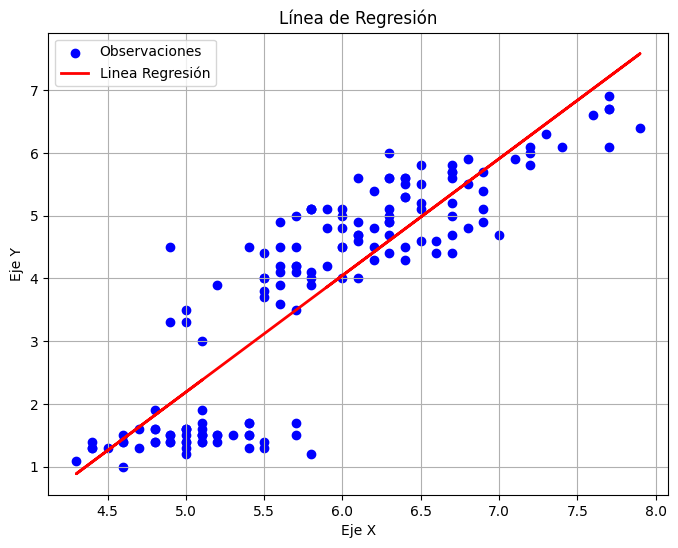

In [16]:
# Graficar Linea de Regresión
plt.figure(figsize=(8, 6))
plt.scatter(A, B, color='blue', marker = 'o', label='Observaciones')
plt.plot(A, B_pred, color='red', linewidth = 2, label='Linea Regresión') # Línea de regresión
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Línea de Regresión')
plt.legend()
plt.grid(True)

# Muestra el gráfico
plt.show()

In [17]:
# Creando el modelo de tipo Regresión Lineal.
model = LinearRegression()

In [18]:
# Ejemplo de reshape de arrays
arr = np.array([1, 2, 3, 4, 5, 6])
reshaped_arr = arr.reshape(2, 3)

In [19]:
# Model Fit aplicando reshape de A y B con rango entre -1 y 1.
model.fit(A.reshape(-1, 1), B.reshape(-1, 1))

LinearRegression()

In [20]:
# Generando el coeficiente del modelo.
model.coef_

array([[1.85843298]])

In [21]:
# Generando el intercept del modelo.
model.intercept_

array([-7.10144337])